# 🤖 1. Full Preprocessing Deep Learning Models - with Dropouts
**Deep learning models for retinal fundus image classification and refractive error regression**

The purpose of this notebook is to implement and evaluate deep learning models for both binary myopia classification and spherical equivalent (SE) regression using fully preprocessed retinal fundus images. The dataset contains clinically acquired retinal fundus images linked to demographic and refractive information extracted from ophthalmological consultations. It consists of xx fundus images.

In this stage of the project, the objectives are:
- To evaluate a lightweight CNN architecture for automated binary myopia classification.
- To evaluate a second CNN architecture adapted for refractive error regression using spherical equivalent (SE) values.

To analyze how fully preprocessed retinal fundus images behave in both classification and regression tasks.
These initial experiments will serve as a foundation for more advanced approaches (e.g., finding out which preprocessing step pushed models to do better), while highlighting the trade-offs between model complexity, training time, and classification accuracy.

The relevance of this work lies in its potential contribution to automated ophthalmology screening tools, aiming for faster and more accessible detection of myopia.

## ⚙️ 1. Setting up

Create a deterministic Train/Val/Test split (satrtified)

Building a DataFrame with image paths and labels. Splitting the dataset into train, validation, and test sets (80/10/10) with stratification to keep class balance (avoids bias if one class bigger than the other).

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os, random

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    get_experiment_paths,
    validate_main_structure,
    validate_experiment_paths,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, "full_preproc")
validate_experiment_paths(exp_paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

TABLE_PATH = exp_paths["table"]

SPLIT_DIR_CLASSF = exp_paths["split_classification"]
SPLIT_DIR_REGRSS = exp_paths["split_regression"]

MODELS_DIR_FULL = exp_paths["models_experiment"]
MODELS_DIR_FULL.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR_CLASSF)
print("Regression splits:", SPLIT_DIR_REGRSS)
print("Models output:", MODELS_DIR_FULL)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

df = pd.read_excel(TABLE_PATH)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
Regression splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Keep only images with valid path and existent SE targets
df = df[df["image_path"].notna()].copy()
df = df[df["target_SE"].notna()].copy()
df = df[df["class_label"].notna()].copy()

df["image_path"] = df["image_path"].astype(str)
df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")
df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("int32")

df = df.dropna(
    subset=["image_path", "filename", "patient_id", "target_SE", "class_label"]
).copy()

# Verify paths exist before training
missing_paths = df["image_path"].apply(lambda p: not Path(p).exists()).sum()
print("Missing image paths:", missing_paths)

assert missing_paths == 0, "Some image paths do not exist. Check the FullPreproc match table."

Missing image paths: 0


In [3]:
df["class_label"] = df["class_label"].astype("int32")
print("Total valid images (with SE):", len(df))
print("\nClassification label balance (0 = non-myopic, 1 = myopic)")
print(df["class_label"].value_counts())
print("\nTarget SE summary:")
print(df["target_SE"].describe())

Total valid images (with SE): 2126

Classification label balance (0 = non-myopic, 1 = myopic)
class_label
0    1645
1     481
Name: count, dtype: int64

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


#### 1.2. Train/Val/Test split

In [4]:
# Stratified 80/10/10 split
# Stratification is done using the classification label from the matches table to keep myopia/normal balance across splits
train_df, tmp_df = train_test_split(df, test_size=0.2, stratify=df["class_label"], random_state=SEED, shuffle=True) #first a temp 80% and 20% split
val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df["class_label"], random_state=SEED, shuffle=True) #then 10% validation, 10% test

#saving all 3 sets into different CSVs
# Save classification splits
train_df.to_csv(SPLIT_DIR_CLASSF / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR_CLASSF / "val.csv", index=False)
test_df.to_csv(SPLIT_DIR_CLASSF / "test.csv", index=False)

# Save regression splits
# Same rows, different target used later by dataloader
train_df.to_csv(SPLIT_DIR_REGRSS / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR_REGRSS / "val.csv", index=False)
test_df.to_csv(SPLIT_DIR_REGRSS / "test.csv", index=False)
    
len(train_df), len(val_df), len(test_df) #making sure split was done correctly

(1700, 213, 213)

#### 1.3. Building TF datasets

Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

def decode_img(path, y):
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) # decodes jpg into RGB tensor
    img = tf.image.convert_image_dtype(img, tf.float32)  # converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear') #rescales to 224x224
    return img, y #gives pic+corresponding label/target

# Lightweight augmentations
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])


In [6]:
def make_classification_ds(csv_path, training=False): #creating the TensorFlow dataset for binary classf
    df_split = pd.read_csv(csv_path)
    paths = df_split["image_path"].astype(str).values
    labels = df_split["class_label"].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

def make_regression_ds(csv_path, training=False): #creating the TensorFlow dataset for SE regrss
    df_split = pd.read_csv(csv_path)
    
    paths = df_split["image_path"].astype(str).values
    targets = df_split["target_SE"].astype("float32").values
    
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True) 
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

In [7]:
train_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "train.csv", training=True) #shuffle + augmentations
val_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "test.csv", training=False) #decode + batching (no augs)

train_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "train.csv", training=True) #shuffle + augmentations
val_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "test.csv", training=False) #decode + batching (no augs)

## 🧩 2. The models

#### 🟢 2.1. First model: small_cnn_classification
Now, we define our first small CNN for binary classification, that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

In [8]:
def build_small_cnn_classf(input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="sigmoid")(x) #binary exit (1 is the probability of myopia)
    return keras.Model(inputs, outputs)

model_classf = build_small_cnn_classf()

model_classf.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with lr=1e-3
              loss="binary_crossentropy", #adecuate for binary classification with sigmoid
              metrics=[keras.metrics.AUC(name="auc"), "accuracy"]) #AUC and accuracy metrics  

In [9]:
model_classf.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️2.1.2. Callbacks for classification
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [10]:
# Building callbacks for later use
cb_classf = [ 
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_auc", mode="max", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

from sklearn.utils.class_weight import compute_class_weight

# Load train split
train_df_classf = pd.read_csv(SPLIT_DIR_CLASSF / "train.csv")

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=train_df["class_label"].astype(int).values) #calcultes inverse weights to teh frecuency of each class
class_weight = {0: float(weights[0]), 1: float(weights[1])} #dictionary understood by keras
print("Class weights:", class_weight)

Class weights: {0: 0.6463878326996197, 1: 2.207792207792208}


#### 2.1.3 Training classification model

In [11]:
history_classf = model_classf.fit(train_ds_classf, validation_data=val_ds_classf, epochs=10, callbacks=cb_classf, class_weight=class_weight) 
# Proper training using our tf.data pipelines (train_ds, val_ds):
# Applies class_weight to penalize errors on the minority class more strongly
# Runs for up to 10 epochs, but EarlyStopping may stop earlier if val_auc does not improve

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.5405 - auc: 0.4851 - loss: 0.6866 - val_accuracy: 0.2958 - val_auc: 0.5770 - val_loss: 0.7012 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.3614 - auc: 0.4698 - loss: 0.6986 - val_accuracy: 0.6244 - val_auc: 0.6127 - val_loss: 0.6882 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.4494 - auc: 0.4927 - loss: 0.7074 - val_accuracy: 0.5728 - val_auc: 0.6287 - val_loss: 0.6843 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4451 - auc: 0.5302 - loss: 0.6969 - val_accuracy: 0.3756 - val_auc: 0.6290 - val_loss: 0.6962 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.3822 - auc: 0.5484 - loss: 0.6991 - val_accuracy: 0.6901 - val_auc: 0.6468 - val_loss: 0.6739 - learning_rate: 0.0010
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5587 - auc: 0.5054 - loss:

In [12]:
test_metrics_classf = history_classf.model.evaluate(test_ds_classf, return_dict=True)
test_metrics_classf

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step - accuracy: 0.6464 - auc: 0.5884 - loss: 0.6794


{'accuracy': 0.65727698802948,
 'auc': 0.5756944417953491,
 'loss': 0.6800066232681274}

Note: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Let's see how our model did:


Taking a first look, it seems as the model did a pretty god job, having got an **accuracy of xxx% and an AUC of xxx%**. Let's see how the performance changes applying a regression model.

#### 🟠 2.2 Second model: small_cnn_regression
The same lightweight CNN backbone is adapted for refractive error regression by replacing the sigmoid classification head with a linear output neuron predicting continuous spherical equivalent (SE) values.

In [13]:
def build_small_cnn_regrss(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="linear")(x) # Regression output: one continuous value, e.g. -2.75 diopters
    return keras.Model(inputs, outputs)

model_regrss = build_small_cnn_regrss()

model_regrss.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with low error 
        loss="mse", #adecuate for regression calculations (Mean Squared Error)
        metrics=[keras.metrics.MeanAbsoluteError(name="mae"), keras.metrics.MeanSquaredError(name="mse")]) #Mean Absolute Error and accuracy metrics

Let's see how our model did:

In [14]:
model_regrss.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️2.2.2. Callbacks for regression

In [15]:
cb_regrss = [ 
    keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True), #if MAE not lower after 5 epochs, stop training and go back to best weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_mae", mode="min", factor=0.3, patience=2),#if MAE stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

#### 2.2.3 Training regression model

In [16]:
history_regrss = model_regrss.fit(train_ds_regrss, validation_data=val_ds_regrss, epochs=10, callbacks=cb_regrss) 
# Proper training using our tf.data regression pipelines
# The model learns to predict a continuous SE value in diopters
# Runs for up to 10 epochs, but EarlyStopping may stop it earlier if validation MAE does not improve.

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - loss: 4.6207 - mae: 1.2083 - mse: 4.6207 - val_loss: 4.3002 - val_mae: 1.1465 - val_mse: 4.3002 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 5.2727 - mae: 1.2667 - mse: 5.2727 - val_loss: 4.2776 - val_mae: 1.1901 - val_mse: 4.2776 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - loss: 3.9609 - mae: 1.2013 - mse: 3.9609 - val_loss: 4.2881 - val_mae: 1.1474 - val_mse: 4.2881 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 4.2776 - mae: 1.1924 - mse: 4.2776 - val_loss: 4.2610 - val_mae: 1.1568 - val_mse: 4.2610 - learning_rate: 3.0000e-04
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 5.1319 - mae: 1.3135 - mse: 5.1319 - val_loss: 4.2621 - val_mae: 1.1655 - val_mse: 4.2621 - learning_rate: 3.0000e-04
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 4.1441 - mae: 1.1964 - mse: 4.1441 - val_loss: 4.2330 - val_mae: 1.1663 - 

In [17]:
test_metrics_regrss = history_regrss.model.evaluate(test_ds_regrss, return_dict=True)
test_metrics_regrss

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - loss: 3.2228 - mae: 1.0789 - mse: 3.2228


{'loss': 3.2760121822357178,
 'mae': 1.102931022644043,
 'mse': 3.2760121822357178}

Unexpectedly, this regession model performed worse than our classification small_cnn did, getting **an accuracy of xxx% and an AUC of xxx%** (previous model obtained an accuracy of xxx% and an AUC of xxx%, so better results).

In [18]:
# Save trained models
CLASSF_MODEL_PATH = MODELS_DIR_FULL / "small_cnn_classification_with_dropout_fullpreproc.keras"
REGRSS_MODEL_PATH = MODELS_DIR_FULL / "small_cnn_regression_with_dropout_fullpreproc.keras"

model_classf.save(CLASSF_MODEL_PATH)
model_regrss.save(REGRSS_MODEL_PATH)

print("Classification model saved at:", CLASSF_MODEL_PATH)
print("Regression model saved at:", REGRSS_MODEL_PATH)

Classification model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc\small_cnn_classification_with_dropout_fullpreproc.keras
Regression model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc\small_cnn_regression_with_dropout_fullpreproc.keras


## 📊 3. Results of classification and regression models

#### 📈 3.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for one or multiple Keras models, making it easy to compare performance across epochs.

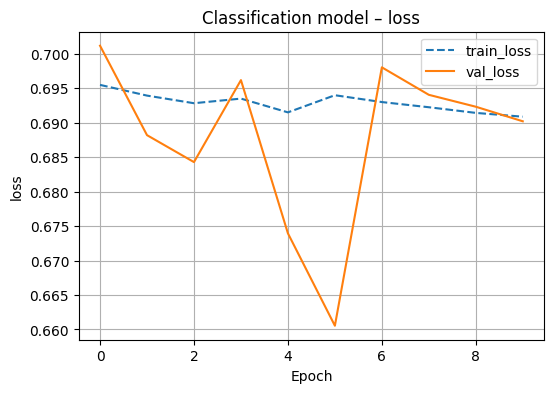

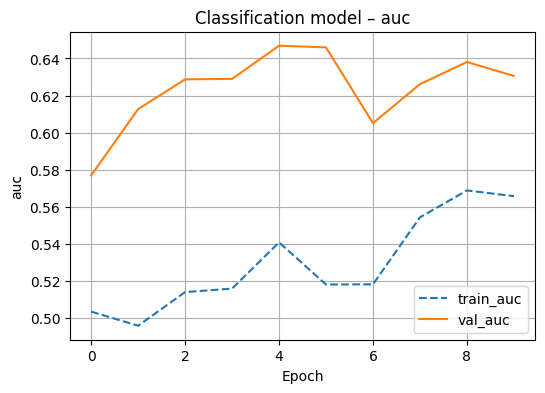

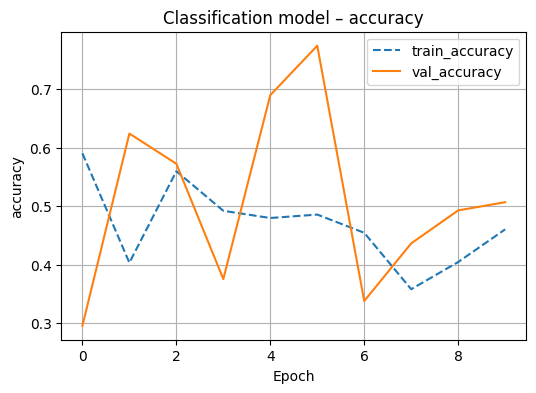

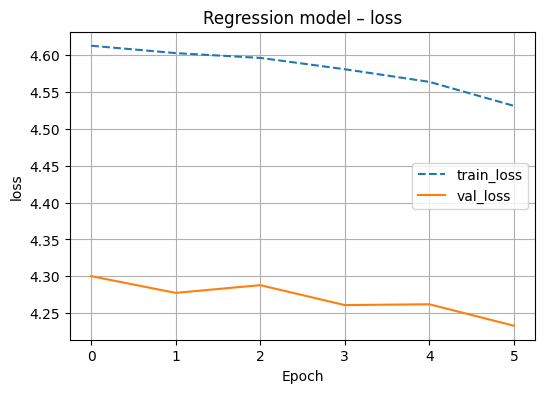

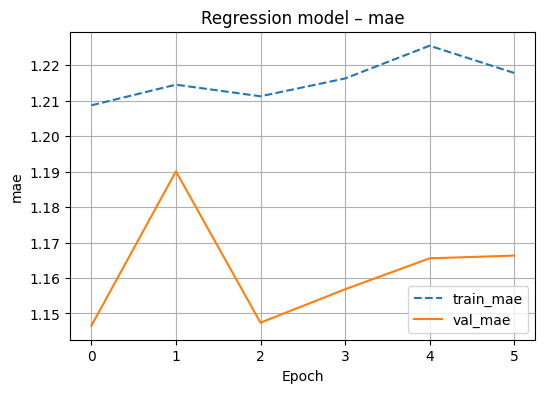

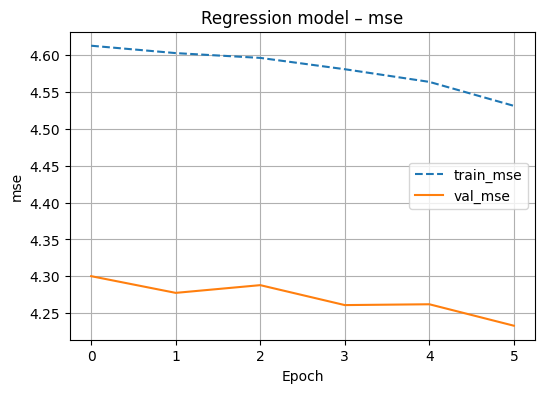

In [19]:
def plot_histories(history, metrics, title):
    #histories: list of keras History objects returned after training
    #metrics: e.g. "auc" | "accuracy" | "loss" -  metrics to visualize during training
    #title: list of names e.g. ["Classification", "Regression"]

    for metric in metrics:
        plt.figure(figsize=(6,4))
        
        if metric in history.history:
            plt.plot(history.history[metric], linestyle="--", label=f"train_{metric}")
        
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(f"{title} – {metric}")
        plt.legend()
        plt.grid(True)
        plt.show()

#classf
plot_histories(
    history_classf,
    metrics=["loss", "auc", "accuracy"],
    title="Classification model"
)

#regrss
plot_histories(
    history_regrss,
    metrics=["loss", "mae", "mse"],
    title="Regression model"
)


It is clear that **both models had a pretty steady AUC curve** along training. On the other hand, the xxx seems to have had a flatter accuracy training curve compared to xxx. 

What is more, the **small_cnn_xxx had a lower level of loss** along all epochs.

#### 🧪 3.2 Collect predictions & eval on test set
Evaluating trained models on the test set, collecting predictions, plotting ROC and Precision–Recall curves, showing the confusion matrix if there is one, and returning metrics such as AUC, AP, accuracy, and a classification report.

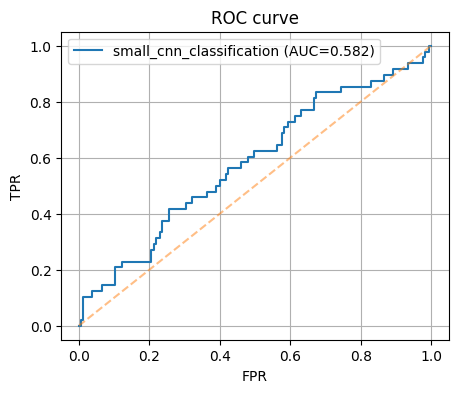

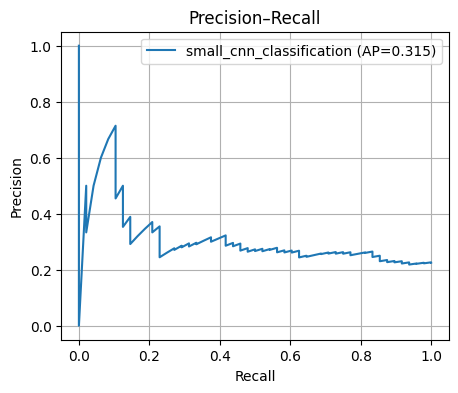

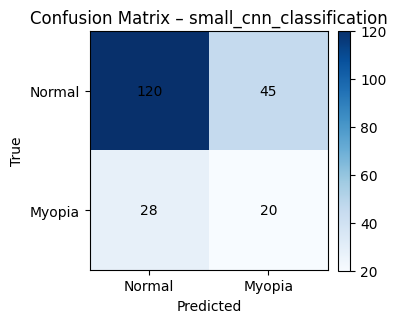

              precision    recall  f1-score   support

      Normal       0.81      0.73      0.77       165
      Myopia       0.31      0.42      0.35        48

    accuracy                           0.66       213
   macro avg       0.56      0.57      0.56       213
weighted avg       0.70      0.66      0.67       213



In [20]:
#CLASSIFICATION:

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

def collect_classification_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] #true labels 1 or 0; probabilities of model 0-1
    
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    
    return y_true, y_score

def evaluate_classification_on_test(name, model, test_ds, threshold=0.5, show_plots=True):
    y_true, y_score = collect_classification_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    #Metric 1: ROC / PR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    #Metric 2: Confusion matrix & report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Myopia"]
    )

    if show_plots:
        # ROC curve: sensitivity to false positives (True Positive Rate vs False Positive Rate)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0,1], [0,1], "--", alpha=0.5)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("ROC curve")
        plt.grid(True)
        plt.legend()
        plt.show()

        # PR: precission vs recall
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Confusion matrix: TP/TN/FP/FN
        plt.figure(figsize=(4,3.6))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"Confusion Matrix – {name}")
        plt.xticks([0,1], ["Normal", "Myopia"])
        plt.yticks([0,1], ["Normal", "Myopia"])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return {
        "name": name,
        "AUC": float(roc_auc), #Quality of segreggation
        "AP": float(ap),
        "accuracy@0.5": float((y_pred == y_true).mean()), #% Correctness
        "confusion_matrix": cm,
        "report": report
    }

# Example usage:
res_classf = evaluate_classification_on_test(
    "small_cnn_classification",
    model_classf,
    test_ds_classf
)

print(res_classf["report"])

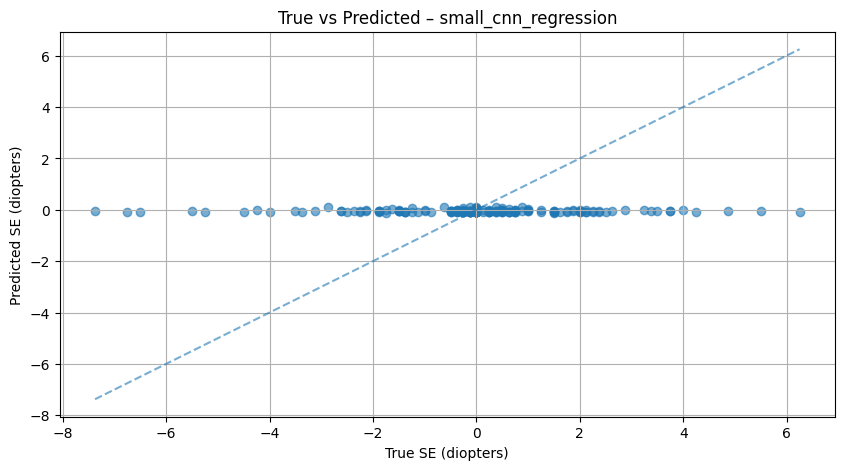

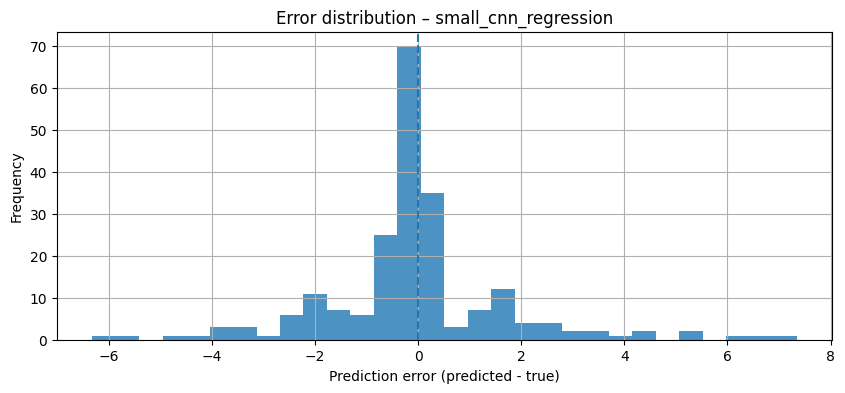

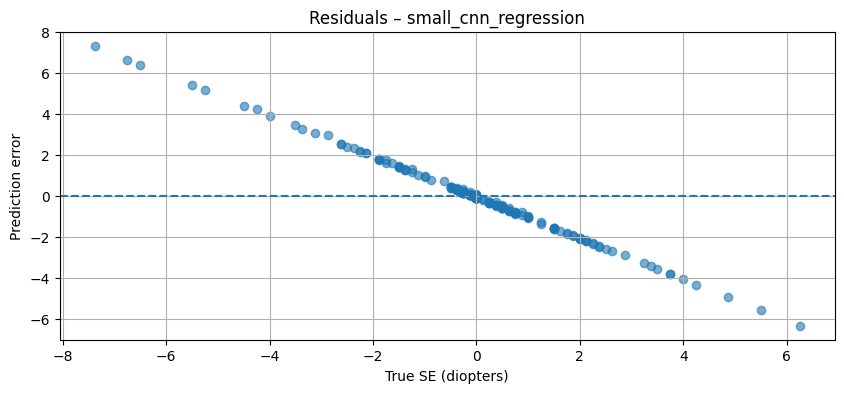

{'name': 'small_cnn_regression',
 'MAE': 1.1029309595983143,
 'MSE': 3.276012276306075,
 'RMSE': 1.8099757667731562,
 'R2': -2.9190660426614556e-05}

In [21]:
#REGRESSION:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def collect_regression_preds(model, ds): #dataset as ds
    y_true, y_pred = [], [] # True SE values and predicted SE values
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(p.tolist())
    
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    
    return y_true, y_pred

def evaluate_regression_on_test(name, model, test_ds, show_plots=True):
    y_true, y_pred = collect_regression_preds(model, test_ds)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    errors = y_pred - y_true

    if show_plots:
        # true vs predicted SE values
        plt.figure(figsize=(10,5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)

        plt.xlabel("True SE (diopters)")
        plt.ylabel("Predicted SE (diopters)")
        plt.title(f"True vs Predicted – {name}")
        plt.grid(True)
        plt.show()
        
        # Distribution of prediction errors
        plt.figure(figsize=(10,4))
        plt.hist(errors, bins=30, alpha=0.8)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Prediction error (predicted - true)")
        plt.ylabel("Frequency")
        plt.title(f"Error distribution – {name}")
        plt.grid(True)
        plt.show()

        # # Residual plot: relationship between prediction error and true SE
        plt.figure(figsize=(10,4))
        plt.scatter(y_true, errors, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("True SE (diopters)")
        plt.ylabel("Prediction error")
        plt.title(f"Residuals – {name}")
        plt.grid(True)
        plt.show()

    return {
        "name": name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

#Example usage:
res_regrss = evaluate_regression_on_test(
    "small_cnn_regression",
    model_regrss,
    test_ds_regrss
)

res_regrss

For **our small_cnn_xxx** we can see very close-to-90-degrees ROC and precision-recall curves, which proves good results. Also, its confusion matrix points out very low errors in the test set, these being around **xxx% mistakes from trying to classify all the dataset**.

On the other hand, our xxx model **(xxx) got rounder curves and a slightly higher percentage of errors (xxx%)**.

#### ⚖️ 3.3 Direct comparison: classification and regression experiments
This code evaluates both models on the same test set to compare their performance directly.

In [22]:
summary_results = pd.DataFrame([
    {
        "model": "small_cnn_classification",
        "task": "classification",
        "test_auc": res_classf["AUC"],
        "test_ap": res_classf["AP"],
        "test_accuracy@0.5": res_classf["accuracy@0.5"],
        "test_mae": np.nan,
        "test_mse": np.nan,
        "test_rmse": np.nan,
        "test_r2": np.nan
    },
    {
        "model": "small_cnn_regression",
        "task": "regression",
        "test_auc": np.nan,
        "test_ap": np.nan,
        "test_accuracy@0.5": np.nan,
        "test_mae": res_regrss["MAE"],
        "test_mse": res_regrss["MSE"],
        "test_rmse": res_regrss["RMSE"],
        "test_r2": res_regrss["R2"]
    }
])

summary_results

,model,task,test_auc,test_ap,test_accuracy@0.5,test_mae,test_mse,test_rmse,test_r2
0,small_cnn_classification,classification,0.582197,0.315384,0.657277,NaN,NaN,NaN,NaN
1,small_cnn_regression,regression,NaN,NaN,NaN,1.102931,3.276012,1.809976,-0.000029


Indeed, we got rounder curves for the learning model on both metrics whereas our **small_cnn_xxx got rought edges (better)**.

#### 🗂️ 3.4 Quick “experiment card” (dict of results)
This function summarizes a training experiment, extracting config details, best validation metrics, and test results, and organizes them into a dictionary that can be displayed as a comparison table.

In [23]:
def summarize_classification_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "classification",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_auc": float(np.max(history.history.get("val_auc", [np.nan]))),
        "best_val_acc": float(np.max(history.history.get("val_accuracy", [np.nan]))),
        "test_auc": test_metrics_dict["AUC"],
        "test_ap": test_metrics_dict["AP"],
        "test_acc@0.5": test_metrics_dict["accuracy@0.5"]
    }
    return summary

def summarize_regression_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "regression",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_mae": float(np.min(history.history.get("val_mae", [np.nan]))),
        "best_val_mse": float(np.min(history.history.get("val_mse", [np.nan]))),
        "test_mae": test_metrics_dict["MAE"],
        "test_mse": test_metrics_dict["MSE"],
        "test_rmse": test_metrics_dict["RMSE"],
        "test_r2": test_metrics_dict["R2"]
    }

    return summary

In [24]:
class CFG:
    INPUT_TABLE = TABLE_PATH
    IMAGE_SIZE = 224                  # final square size (e.g., 224 tamaño og, 256 tamaño habitual ImageNet, 299)
    APPLY_CLAHE = True                # cCntrast Limited Adaptive Histogram Equalization
    CLAHE_MODE = "luminance"          # choosing CLAHE channel from "luminance" | "green" | "blue" | "none"
    NORMALIZATION = "0-1"             # "0-1" | "zscore" | "imagenet"
    VERBOSE = True                    # gives messages while preprocessing for visual progress

# Example usage:
card_classf = summarize_classification_experiment(
    "small_cnn_classification",
    CFG,
    history_classf,
    res_classf
)

card_regrss = summarize_regression_experiment(
    "small_cnn_regression",
    CFG,
    history_regrss,
    res_regrss
)

pd.DataFrame([card_classf, card_regrss])

,name,task,image_size,clahe,normalization,best_val_auc,best_val_acc,test_auc,test_ap,test_acc@0.5,best_val_mae,best_val_mse,test_mae,test_mse,test_rmse,test_r2
0,small_cnn_classification,classification,224,luminance,0-1,0.646843,0.774648,0.582197,0.315384,0.657277,NaN,NaN,NaN,NaN,NaN,NaN
1,small_cnn_regression,regression,224,luminance,0-1,NaN,NaN,NaN,NaN,NaN,1.146526,4.233031,1.102931,3.276012,1.809976,-0.000029


The summary shows how the **xxx model outperforms the xxx model in all categories**: on validation AUC (xxx% vs xxx%), on validation accuracy (xxx% vs xxx%), on test AUC (xxx% vs xxx%), on test accuracy (xxx% vs xxx%) and on test Average Precision (xxx% vs xxx%).

## 📌 5. Conlusions

All in all, we might extract the following conclusions from this first notebook with 2 models of fully-preprocessed-pictures:
- All metrics (validation AUC, val accuracy, test AUC, test acc, test Average Precision) show this order of performances: **small_cnn_xxx > small_cnn_xxx** (for exact values, look for summaries below code boxes).
- Perhaps the most significant results are **test accuracies: xxx% (xxx) vs xxx% (xxx).**

Nevertheless, such great results lead to thinking **perhaps fully preprocessed pictures are key**, and less preprocessing must be tested first to lay some baseline for the project. Let's move on to see which preprocessing element affects results the most, using different preprocessing scenarios.

End :)

In [25]:
y_train_true, y_train_pred = collect_regression_preds(model_regrss, train_ds_regrss)

train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_mse = mean_squared_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_true, y_train_pred)

print("Train MAE :", train_mae)
print("Train RMSE:", train_rmse)
print("Train R²  :", train_r2)

Train MAE : 1.2043272286338513
Train RMSE: 2.144638147916108
Train R²  : 0.00263546660227143


In [26]:
print("Train mean prediction:", np.mean(y_train_pred))
print("Train std prediction :", np.std(y_train_pred))

print("Train mean target    :", np.mean(y_train_true))
print("Train std target     :", np.std(y_train_true))

Train mean prediction: -0.04529678485137137
Train std prediction : 0.04551058827512052
Train mean target    : 0.010514705882352942
Train std target     : 2.1474698073111873


In [27]:
print("Pred min:", y_train_pred.min())
print("Pred max:", y_train_pred.max())

print("True min:", y_train_true.min())
print("True max:", y_train_true.max())

Pred min: -0.12174549698829651
Pred max: 0.1310916244983673
True min: -20.375
True max: 8.625


-> con esta arquitectura y esta información visual, el modelo no es capaz de extraer suficiente información para estimar dioptrías continuas mejor que predecir la media de la población.

In [28]:
train_df["target_SE"].describe()

count    1700.000000
mean        0.010515
std         2.148102
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         8.625000
Name: target_SE, dtype: float64

In [29]:
y_mean = np.mean(y_train_true)

y_test_true, y_test_pred = collect_regression_preds(model_regrss, test_ds_regrss)

baseline_pred = np.full_like(y_test_true, y_mean)

print("Baseline MAE:",
      mean_absolute_error(y_test_true, baseline_pred))

print("Baseline RMSE:",
      np.sqrt(mean_squared_error(y_test_true, baseline_pred)))

print("Baseline R2:",
      r2_score(y_test_true, baseline_pred))

Baseline MAE: 1.0933868406517537
Baseline RMSE: 1.8101165076900616
Baseline R2: -0.00018471815407306025


✓ No hay overfitting

✓ No parece un problema de train/test split

✓ No parece un problema de early stopping

✓ No parece un problema de ReduceLROnPlateau

✓ El modelo converge correctamente


✗ El modelo aprende esencialmente la media de la población

✗ No supera al baseline

✗ R² ≈ 0 tanto en train como en test
